SALAD: Sum Absolute value of Local Angular Divergence (SALAD)

Cooks: T. J.-Y. Derrien <derrien@fzu.cz>, J. Sladek, Y. Levy

In [1]:
import skimage.io
import matplotlib.pyplot as plt
import numpy as np

%pwd
%cd Juraj
%pwd
# You can load any of these two lines
image_data = skimage.io.imread("test_LIPSS_DLOA3a.png")
# image_data = skimage.io.imread("test_LIPSS_DLOA_5000.png")

print(image_data.shape)
print(image_data.dtype)

/home/hilase/Documents/spp-extended-theory/LIPSS-database/Juraj
(5000, 5000)
uint8


# Limits of DLOA

## DLOA is a scalar quantity to characterize a 2D function I(x,y)

The Dispersion of LIPSS Orientation Angle (DLOA) proposed in [Gnilitskyi, I.; Derrien, T.; Levy, Y.; Bulgakova, N.; Mocek, T. & Orazi, L. High-speed manufacturing of highly regular femtosecond laser-induced periodic surface structures: physical origin of regularity. Scientific reports, 7, 8485 (2017)]. 

Since:
- DLOA is a scalar value: $DLOA \in \mathbb{R}$,
- image $I(x,y)$ is a 2D-scalar field expressed in cartesian frame,
the DLOA is constructed by performing a double-integration on I(x,y). 

$\text{DLOA}=\iint dx\,dy\,f\left[I\left(x,y\right)\right]$ where $f$ is an operator (for example, the one we have proposed in our Sci. Rep. paper). 

If trying to invert the problem, i.e., finding the image that corresponds to a given DLOA, one obtains a so-called "inverse" problem in the mathematical sense, that is defined by an integral equation, of which the distribution I(x,y) is the unknown. 

By its mathematical definition, an integral equation [https://en.wikipedia.org/wiki/Integral_equation] in a manifold of distributions has classes of solutions, i.e., it does not have a unique solution. For each DLOA, there exists stricly more than 1 picture that would provide the same value of DLOA (for example, the idealized pictures Juraj provided). 

## How to build a better quantity?

To progress in this matter, and to go beyond the DLOA, it is possible to construct a quantity that would account for the local curvature of the isolines (contours), and to cumulate this quantity. 

# Salad

## Flavor 1: local divergence

The isolines $s(x,y)$ are normal to the gradient of the intensity distribution $I(x,y)$. The normal to the gradient directly writes as $\vec{n}(x,y)=\vec{\nabla} I(x,y)$ and contains the vectorial information of the direction of the LIPSS. 

Since we are interested only in the variation of the orientation angle, we can substitute the isolines by its normal vector field, without loosing physical substance of the observable we are constructing. 

Now we would like to construct the spatial variation of this vector field $\vec{\nabla} (x,y)$. For this, we simply employ the divergence operator, that contains the dispersion of the angle from its neightbours in the vector-field. We call this quantity **local dispersion** $LD$ which can write as $LD (x,y) = \vec{\nabla} \cdot \vec{\nabla} I(x,y) = \vec{\nabla^2} I(x,y)$. 

Finally, since we are interested in how these local dispersion is cumulating, we shall introduce an absolute value. As a result, the operator "Sum of Absolute Localized Angular Dispersion" (SALAD) can be defined by 

$SALAD[I(x,y)] = \iint dx \, dy\, \left| LD(x,y) \right| = \iint dx \, dy \, \left|
\vec{\nabla^2} I(x,y) \right| $.

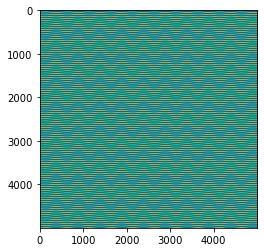

In [2]:
plt.imshow(image_data)

In [3]:
contour=np.gradient(image_data)

In [4]:
contour_t=np.asfarray(contour)
print(contour_t.shape)

(2, 5000, 5000)


We name contour the gradient of the initial picture $I(x,y)$. Result "contour" is a vector $\vec{\nabla} I(x,y) \in \mathbb R^2$ 

"contour_t" is the same information in Numpy format. 

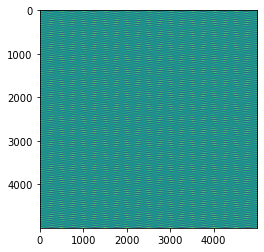

In [5]:
plt.imshow(contour_t[1])

We now prepare the Laplacian of $I(x,y)$. 

In [6]:
# np.gradient(contour_t) #gives a tensor of order 4... not the right thing
dFx=contour_t[0]
dFy=contour_t[1]
ddFx=np.gradient(dFx)
ddFy=np.gradient(dFy)

In [7]:
np.shape(ddFx)


(2, 5000, 5000)

In [8]:
dFxx=ddFx[0]
dFyy=ddFy[1]
laplacian=dFxx+dFyy

In [9]:
np.shape(laplacian)

(5000, 5000)

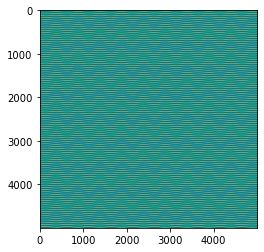

In [10]:
plt.imshow(laplacian)

Laplacian of the picture $\vec{\nabla}^2 I(x,y)$ was obtained. It contains the information about local angular dispersion of the initial picture. 

We now construct the $SALAD$ operator defined above (in its Flavor 1). 

In [11]:
SaladBowl=np.abs(laplacian)

In [12]:
Salad=np.sum(laplacian)
print(Salad)

4329.0


SALAD(picture1) = 4239

We also applied this method to the second picture. 

SALAD(picture2)  = 4242.75.

Unfortunately, a very small difference is visible, although the figures have been ideally defined. 

The problem of this SALAD quantity is now that is it not intuitive / not very good. 
At least, the DLOA is not perfect but it is intuitive. 

## Next step?

Maybe visualization of the prepared vector fields would help to study the origin of the problem.

Source: https://scipython.com/blog/visualizing-a-vector-field-with-matplotlib/

(5000,) (5000,) (5000, 5000) (5000, 5000)


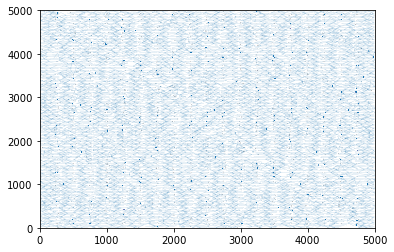

In [13]:
x=np.linspace(0,len(image_data),5000)
y=x
print(np.shape(x), np.shape(y), np.shape(contour_t[0]), np.shape(contour_t[1]))

plt.streamplot(x,y,contour_t[0], contour_t[1], linewidth=0.1, cmap=plt.cm.inferno,
              density=5, arrowstyle='->', arrowsize=1.5)

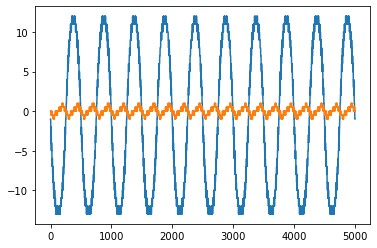

In [14]:
plt.plot(x,contour_t[0][0])
plt.plot(y,contour_t[1][0])

It seems Juraj's ideal pictures were prepared in view of having 
$\int dx\, I(x,y) = 0$ and $\int dy\, I(x,y) = 0$, that of course screws analysis based on spatial integration. Clever boy! 